In [1]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [8]:
class BMISTATE(TypedDict):

    weight_kg:float
    height_m:float
    bmi:float
    category:str
    
    

In [9]:
def caluculateBMI(state:BMISTATE) ->BMISTATE:

    weight=state['weight_kg']
    height=state['height_m']
    answ=weight/height**2
    state['bmi']=round(answ,8)

    return state


In [10]:
def categoryBMI(state:BMISTATE) ->BMISTATE:
    var=state['bmi']
    if var < 18.5:
        state['category']='Underweight'
    elif var >= 18.5 and var< 25:
        state['category']='Healthyweight'
    else:
        state['category']='obese'

    return state

In [14]:
graph=StateGraph(BMISTATE)

graph.add_node('caluculate_BMI',caluculateBMI)

graph.add_node('categoryBMI',categoryBMI)

graph.add_edge(START,'caluculate_BMI')

graph.add_edge('caluculate_BMI','categoryBMI')

graph.add_edge('categoryBMI',END)

workflow=graph.compile()

In [15]:
input_state={'weight_kg':80,'height_m':1.73}

output_state=workflow.invoke(input_state)

In [16]:
print(output_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.7299275, 'category': 'obese'}


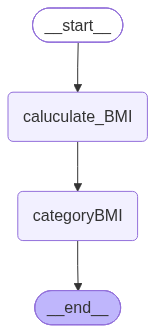

In [17]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())